In [1]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [2]:

#生成数据集
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)! x^i / i!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [3]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[-1.6538],
         [-2.6628]]),
 tensor([[ 1.0000e+00, -1.6538e+00,  1.3675e+00, -7.5386e-01,  3.1168e-01,
          -1.0309e-01,  2.8415e-02, -6.7132e-03,  1.3878e-03, -2.5501e-04,
           4.2174e-05, -6.3406e-06,  8.7383e-07, -1.1116e-07,  1.3132e-08,
          -1.4478e-09,  1.4965e-10, -1.4558e-11,  1.3375e-12, -1.1642e-13],
         [ 1.0000e+00, -2.6628e+00,  3.5453e+00, -3.1468e+00,  2.0949e+00,
          -1.1156e+00,  4.9513e-01, -1.8835e-01,  6.2692e-02, -1.8548e-02,
           4.9391e-03, -1.1956e-03,  2.6531e-04, -5.4345e-05,  1.0336e-05,
          -1.8349e-06,  3.0538e-07, -4.7834e-08,  7.0762e-09, -9.9172e-10]]),
 tensor([ -5.8286, -27.9501]))

In [4]:
#评估损失函数
def evaluate_loss(net, data_iter, loss):
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [5]:
#定义训练函数
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')#均方误差损失
    input_shape = train_features.shape[-1]

    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',xlim=[1, num_epochs], ylim=[1e-3, 1e2],legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

weight: [[ 5.0025473  1.1778616 -3.408023   5.643362 ]]


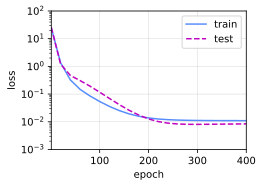

In [6]:
#三阶多项式函数拟合(正常)
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[2.9874408 3.8778625]]


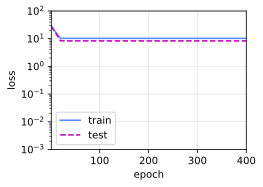

In [10]:
#线性函数拟合(欠拟合)
train(poly_features[:n_train, :2], poly_features[n_train:, :2],labels[:n_train], labels[n_train:])#只用了前2个特征

weight: [[ 4.9906254   1.2395484  -3.363315    5.32416    -0.13167793  0.95183504
   0.37391916  0.01077753 -0.17209493 -0.07017866  0.12027595 -0.18869342
  -0.1444177   0.13772291 -0.12120046 -0.0443224   0.04865815  0.10967213
  -0.12388617  0.05958107]]


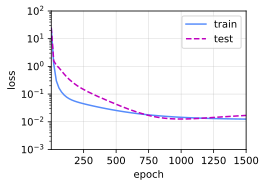

In [8]:
#高阶多项式函数拟合(过拟合)
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],labels[:n_train], labels[n_train:], num_epochs=1500)#训练轮数增加到1500